# PSSNa Curve-Fit Data Preparation

Load the 55C R0 Iqxy detector files, radially average each detector range, scale overlaps onto the mid-Q range, and stitch a single experimental observation for later fitting.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import cf_tools as cf

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Parameter Settings

In [2]:
# DATA_DIR = Path("data/yyw/4_5wt")
# SAMPLE_TAG = "55C_R0"
DATA_DIR = Path("data/yyw/1_5wt")
SAMPLE_TAG = "55B_R0"

IQXY_FILES = {
    "lowQ": DATA_DIR / f"{SAMPLE_TAG}_lowQ_Iqxy.dat",
    "midQ": DATA_DIR / f"{SAMPLE_TAG}_midQ_Iqxy.dat",
    "highQ": DATA_DIR / f"{SAMPLE_TAG}_highQ_Iqxy.dat",
}

REFERENCE_RANGE = "midQ"
RADIAL_BINS_PER_RANGE = 90
STITCHED_BINS = 180
MIN_PIXELS_PER_RADIAL_BIN = 6

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OBSERVATION_CSV = OUTPUT_DIR / f"{SAMPLE_TAG}_stitched_observation.csv"

# Current fitting/anchor window for the experimental observation.
FIT_Q_MIN = 1.5e-3
FIT_Q_MAX = 4.0e-1
LOWQ_ANCHOR_BOUNDS = (FIT_Q_MIN, 8.0e-3)
HIGHQ_ANCHOR_BOUNDS = (8.0e-2, FIT_Q_MAX)
PEAK_GUESS_BOUNDS = (3.0e-2, 1.1e-1)
# None means each anchor fit uses min positive observed intensity in its window.
ANCHOR_BACKGROUND_MAX = 1e-10
SUBTRACT_BG = True

print(f"[status] sample={SAMPLE_TAG}")
for label, path in IQXY_FILES.items():
    print(f"[status] {label}: {path}")

[status] sample=55B_R0
[status] lowQ: data\yyw\1_5wt\55B_R0_lowQ_Iqxy.dat
[status] midQ: data\yyw\1_5wt\55B_R0_midQ_Iqxy.dat
[status] highQ: data\yyw\1_5wt\55B_R0_highQ_Iqxy.dat


## Load And Radially Average

In [3]:
raw_iqxy = {label: cf.load_iqxy(path, label=label) for label, path in IQXY_FILES.items()}
profiles = {
    label: cf.radial_average_iqxy(
        data,
        n_bins=RADIAL_BINS_PER_RANGE,
        min_count=MIN_PIXELS_PER_RADIAL_BIN,
    )
    for label, data in raw_iqxy.items()
}

for label, profile in profiles.items():
    print(
        f"[status] {label}: raw_pixels={raw_iqxy[label].q.size}, "
        f"radial_bins={profile.q.size}, "
        f"Q=[{profile.q.min():.4g}, {profile.q.max():.4g}]"
    )

[status] lowQ: raw_pixels=9409, radial_bins=64, Q=[0.00103, 0.02083]
[status] midQ: raw_pixels=9903, radial_bins=74, Q=[0.008101, 0.1134]
[status] highQ: raw_pixels=10437, radial_bins=73, Q=[0.03823, 0.4991]


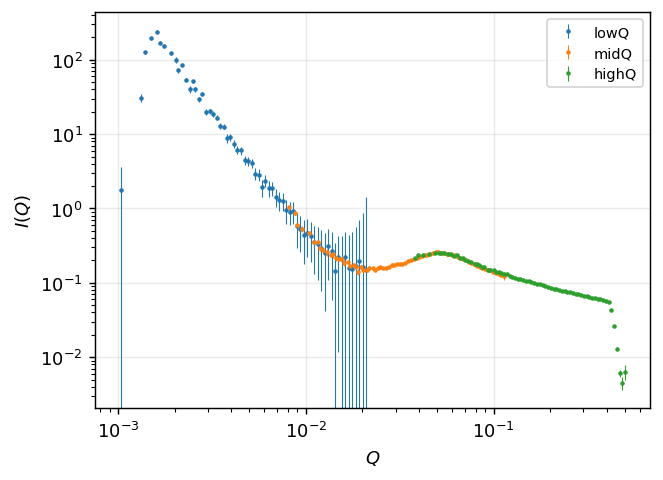

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 3.8))
for label in ("lowQ", "midQ", "highQ"):
    profile = profiles[label]
    positive = profile.intensity > 0.0
    ax.errorbar(
        profile.q[positive],
        profile.intensity[positive],
        yerr=profile.error[positive],
        fmt=".",
        ms=3,
        lw=0.6,
        capsize=0,
        label=label,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()

## Overlap Scaling And Stitching

In [5]:
reference = profiles[REFERENCE_RANGE]
scaled_profiles = {REFERENCE_RANGE: reference}
scale_reports = {REFERENCE_RANGE: {"scale": 1.0, "n_overlap": reference.q.size}}

for label, profile in profiles.items():
    if label == REFERENCE_RANGE:
        continue
    scaled, report = cf.scale_profile_to_reference(profile, reference)
    scaled_profiles[label] = scaled
    scale_reports[label] = report

for label in ("lowQ", "midQ", "highQ"):
    report = scale_reports[label]
    print(f"[status] {label}: scale={report['scale']:.6g}, overlap_points={report['n_overlap']}")

stitched_raw = cf.stitch_profiles(scaled_profiles, n_bins=STITCHED_BINS)
stitched = stitched_raw
print(f"[status] stitched bins={stitched.q.size}, Q=[{stitched.q.min():.4g}, {stitched.q.max():.4g}]")

[status] lowQ: scale=0.997657, overlap_points=23
[status] midQ: scale=1, overlap_points=74
[status] highQ: scale=0.982218, overlap_points=28
[status] stitched bins=159, Q=[0.00103, 0.4838]


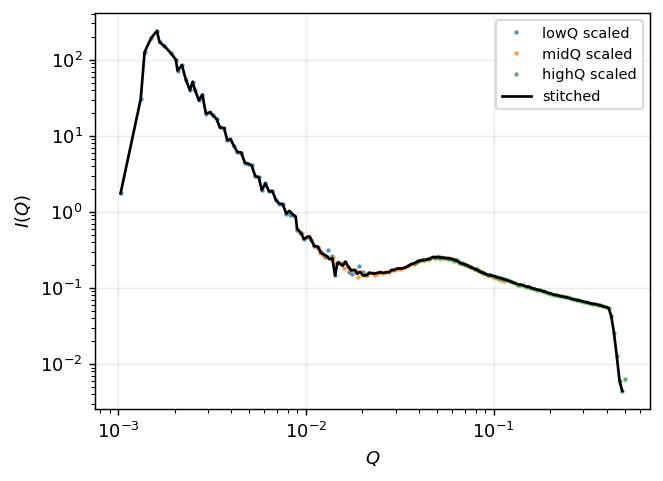

In [6]:
fig, ax = plt.subplots(figsize=(5.2, 3.8))
for label in ("lowQ", "midQ", "highQ"):
    profile = scaled_profiles[label]
    positive = profile.intensity > 0.0
    ax.plot(profile.q[positive], profile.intensity[positive], ".", ms=3, alpha=0.65, label=f"{label} scaled")
positive = stitched.intensity > 0.0
ax.plot(stitched.q[positive], stitched.intensity[positive], "k-", lw=1.5, label="stitched")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()

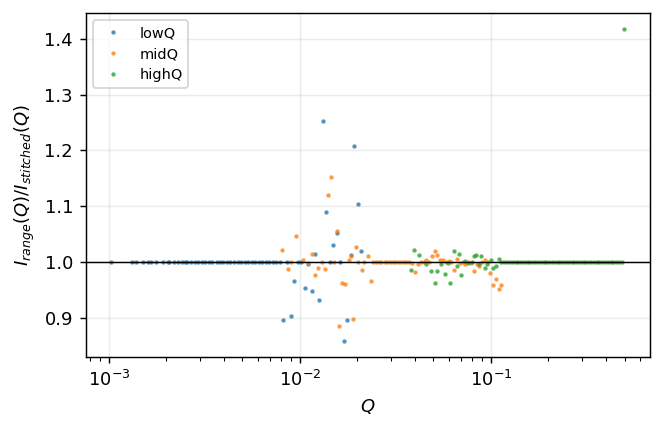

In [7]:
fig, ax = plt.subplots(figsize=(5.2, 3.4))
for label in ("lowQ", "midQ", "highQ"):
    profile = scaled_profiles[label]
    interp_stitched = np.interp(np.log(profile.q), np.log(stitched.q), stitched.intensity)
    ratio = profile.intensity / interp_stitched
    good = np.isfinite(ratio) & (profile.intensity > 0.0) & (interp_stitched > 0.0)
    ax.semilogx(profile.q[good], ratio[good], ".", ms=3, alpha=0.65, label=label)
ax.axhline(1.0, color="k", lw=0.8)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I_{range}(Q)/I_{stitched}(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()

## Asymptote Anchor Fits

Use the selected experimental window to get cheap initial guesses before running the full five-parameter heterogeneous-line fit. These are visual anchors only: the final fit should still use the coupled model.

In [8]:
stitched = stitched_raw
background_subtracted = 0.0
if SUBTRACT_BG:
    highq_background_fit = cf.fit_highq_line_anchor(
        stitched_raw,
        HIGHQ_ANCHOR_BOUNDS,
        allow_signed_background=True,
    )
    background_subtracted = highq_background_fit.parameters["background"]
    stitched = cf.subtract_constant_background(stitched_raw, background_subtracted)

fit_window = (stitched.q >= FIT_Q_MIN) & (stitched.q <= FIT_Q_MAX) & (stitched.intensity > 0.0)
q_fit_grid = np.geomspace(FIT_Q_MIN, FIT_Q_MAX, 400)
anchor_background_max = 0.0 if SUBTRACT_BG else ANCHOR_BACKGROUND_MAX
if anchor_background_max is None:
    anchor_background_max = float(np.min(stitched.intensity[fit_window]))

np.savetxt(
    OBSERVATION_CSV,
    cf.profile_table(stitched),
    delimiter=",",
    header="Q,I,err,count",
    comments="",
)

lowq_dab_fit = cf.fit_lowq_dab_anchor(stitched, LOWQ_ANCHOR_BOUNDS, background_max=anchor_background_max)
lowq_porod_fit = cf.fit_lowq_porod_anchor(stitched, LOWQ_ANCHOR_BOUNDS, background_max=anchor_background_max)
highq_line_fit = cf.fit_highq_line_anchor(stitched, HIGHQ_ANCHOR_BOUNDS, background_max=anchor_background_max)
peak_guess = cf.estimate_peak_position(stitched, PEAK_GUESS_BOUNDS)
anchor_fits = {
    "lowQ_DAB": lowq_dab_fit,
    "highQ_line": highq_line_fit,
}

print(f"[status] fitting Q window = [{FIT_Q_MIN:.3g}, {FIT_Q_MAX:.3g}]")
print(f"[status] subtract background = {SUBTRACT_BG}, removed B = {background_subtracted:.6g}")
print(f"[status] anchor background max = {anchor_background_max:.6g}")
print(f"[status] saved {OBSERVATION_CSV}")
print(f"[guess] peak position: q_peak={peak_guess['q_peak']:.6g}, I_peak={peak_guess['i_peak']:.6g}")
print(
    "[guess] DAB low-Q: "
    f"kappa={lowq_dab_fit.parameters['kappa']:.6g}, "
    f"amplitude={lowq_dab_fit.parameters['amplitude']:.6g}, "
    f"background={lowq_dab_fit.parameters['background']:.6g}, "
    f"rel_rmse={lowq_dab_fit.relative_rmse:.4g}"
)
print(
    "[guess] Q^-4 low-Q: "
    f"coefficient={lowq_porod_fit.parameters['coefficient']:.6g}, "
    f"background={lowq_porod_fit.parameters['background']:.6g}, "
    f"rel_rmse={lowq_porod_fit.relative_rmse:.4g}"
)
print(
    "[guess] line high-Q: "
    f"coefficient={highq_line_fit.parameters['coefficient']:.6g}, "
    f"rho0_apparent={highq_line_fit.parameters['rho0_apparent']:.6g}, "
    f"background={highq_line_fit.parameters['background']:.6g}, "
    f"rel_rmse={highq_line_fit.relative_rmse:.4g}"
)

anchor_rows = [
    ("subtracted_background", background_subtracted, np.nan, np.nan, np.nan),
    ("peak_position", peak_guess["q_peak"], peak_guess["i_peak"], np.nan, np.nan),
    (
        "lowQ_DAB",
        lowq_dab_fit.parameters["kappa"],
        lowq_dab_fit.parameters["amplitude"],
        lowq_dab_fit.parameters["background"],
        lowq_dab_fit.relative_rmse,
    ),
    (
        "lowQ_Qminus4",
        lowq_porod_fit.parameters["coefficient"],
        np.nan,
        lowq_porod_fit.parameters["background"],
        lowq_porod_fit.relative_rmse,
    ),
    (
        "highQ_line",
        highq_line_fit.parameters["coefficient"],
        highq_line_fit.parameters["rho0_apparent"],
        highq_line_fit.parameters["background"],
        highq_line_fit.relative_rmse,
    ),
]
with open(OUTPUT_DIR / f"{SAMPLE_TAG}_anchor_guesses.csv", "w", encoding="utf-8") as fh:
    fh.write("name,value_1,value_2,background,relative_rmse\n")
    for row in anchor_rows:
        fh.write(",".join(str(value) for value in row) + "\n")


[status] fitting Q window = [0.0015, 0.4]
[status] subtract background = True, removed B = 0.0277762
[status] anchor background max = 0
[status] saved output\55B_R0_stitched_observation.csv
[guess] peak position: q_peak=0.0502042, I_peak=0.226408
[guess] DAB low-Q: kappa=0.00121668, amplitude=2.78741e-09, background=0, rel_rmse=0.1766
[guess] Q^-4 low-Q: coefficient=1.66508e-09, background=0, rel_rmse=0.2976
[guess] line high-Q: coefficient=0.0115209, rho0_apparent=0.00366722, background=0, rel_rmse=0.01154


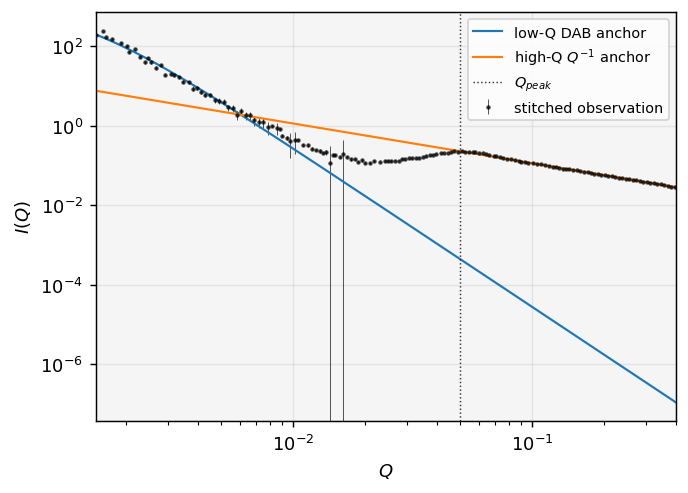

In [9]:
fig, ax = plt.subplots(figsize=(5.4, 3.9))
positive = stitched.intensity > 0.0
ax.errorbar(
    stitched.q[positive],
    stitched.intensity[positive],
    yerr=stitched.error[positive],
    fmt=".",
    ms=3,
    lw=0.55,
    capsize=0,
    color="k",
    alpha=0.65,
    label="stitched observation",
)
ax.plot(q_fit_grid, cf.evaluate_anchor_fit(lowq_dab_fit, q_fit_grid), lw=1.2, label="low-Q DAB anchor")
ax.plot(q_fit_grid, cf.evaluate_anchor_fit(highq_line_fit, q_fit_grid), lw=1.2, label=r"high-Q $Q^{-1}$ anchor")
ax.axvspan(FIT_Q_MIN, FIT_Q_MAX, color="0.5", alpha=0.08)
ax.axvline(peak_guess["q_peak"], color="0.2", lw=0.8, ls=":", label=r"$Q_{peak}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.5e-3, 4.0e-1)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_anchor_fits.png")


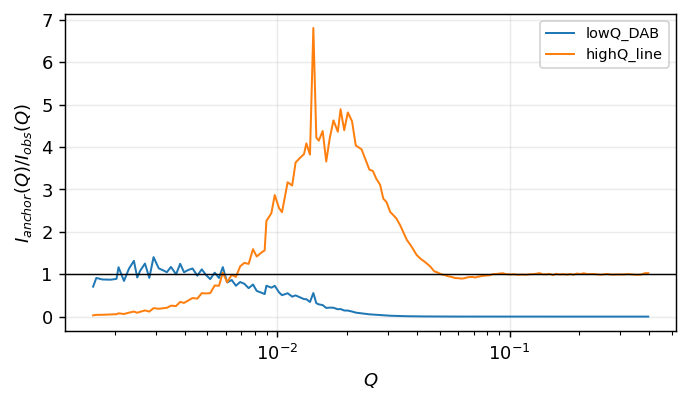

In [10]:
fig, ax = plt.subplots(figsize=(5.4, 3.2))
q_obs = stitched.q[fit_window]
i_obs = stitched.intensity[fit_window]
for label, fit in {"lowQ_DAB": lowq_dab_fit, "highQ_line": highq_line_fit}.items():
    model = cf.evaluate_anchor_fit(fit, q_obs)
    good = np.isfinite(model) & (model > 0.0)
    ax.semilogx(q_obs[good], model[good] / i_obs[good], lw=1.1, label=label)
ax.axhline(1.0, color="k", lw=0.8)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I_{anchor}(Q)/I_{obs}(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_anchor_fit_ratios.png")


## First Constrained Heterogeneous Fit

Fit the smooth heterogeneous-line model over the selected Q range. The search varies `mean_k`, `k_H/k`, `b`, and every entry in `fit_distribution_parameter_set`. The maximum-entropy radial distribution starts with zero third standardized moment (`skewness=0`). The overall scale `A` is solved analytically at each trial. The DAB `kappa_H` and high-Q `A pi p_H rho0` anchors are included as soft residual constraints.

In [11]:
INITIAL_KAPPA_SCALE = 0.5

fit_distribution_parameter_set = {
    "r_sigma_k": {"initial": 0.28, "bounds": (0.27, 0.31)},
    "skewness": {"initial": 0.0, "bounds": (-1.5, 1.5)},
}

fit_initial = cf.initial_heterogeneous_guess_from_anchors(
    q_peak=peak_guess["q_peak"]/1.6,
    lowq_kappa=INITIAL_KAPPA_SCALE * lowq_dab_fit.parameters["kappa"],
    highq_coefficient=highq_line_fit.parameters["coefficient"],
    b0=-1.654,
    r_sigma_k0=0.28,
    distribution_parameter_set=fit_distribution_parameter_set,
)
# override value
fit_initial["k_H_over_k"] = 0.06
fit_initial["r_sigma_k"] = 0.27
fit_initial["b"] = -0.25
fit_initial["mean_k"] = 0.035
fit_bounds = {
    "mean_k": (0.03, 0.04),
    "k_H_over_k": (0.05, 0.25),
    "b": (-2, 2),
}
fit_model_settings = {
    "k_distribution": "max_entropy_radial",
    "regression_loss": "relative",
    "num_modes_k": 2**9,
    "Nr": 2400,
    "Nr_small": 600,
    "N_samp_U": 2**12,
    "N_samp_st": 2**7,
    "NQ": 160,
    "progress": False,
}
print("[status] initial guess")
print(f"  initial_kappa_scale = {INITIAL_KAPPA_SCALE:.6g}")
for key, value in fit_initial.items():
    print(f"  {key} = {value:.6g}")


[status] initial guess
  initial_kappa_scale = 0.5
  scale = 34.2323
  mean_k = 0.035
  r_sigma_k = 0.27
  k_H_over_k = 0.06
  b = -0.25
  skewness = 0


[status] initial model cost=1808.1
[initial] scale = 38.229
[initial] mean_k = 0.035
[initial] r_sigma_k = 0.27
[initial] k_H_over_k = 0.06
[initial] b = -0.25
[initial] k_H = 0.00209914
[initial] p_H = 0.598706
[initial] sigma_H_squared = 0.240257
[initial] alpha_H = 0.000186951
[initial] kappa_H = 0.00077813
[initial] rho0 = 0.000139308
[initial] highq_coefficient = 0.0100169
[initial] skewness = 0


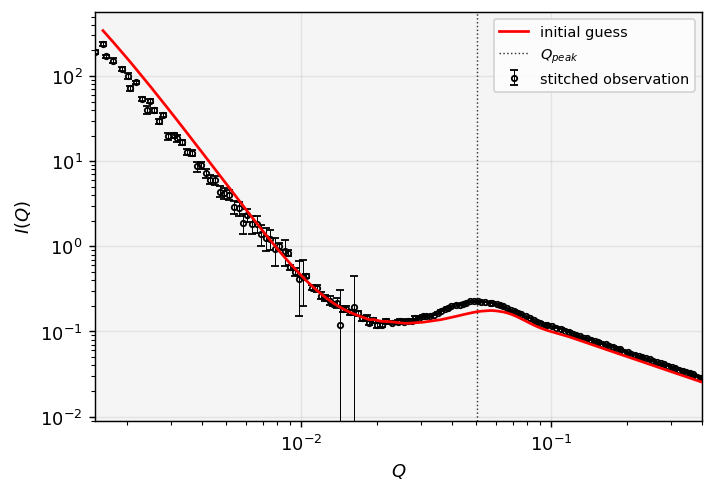

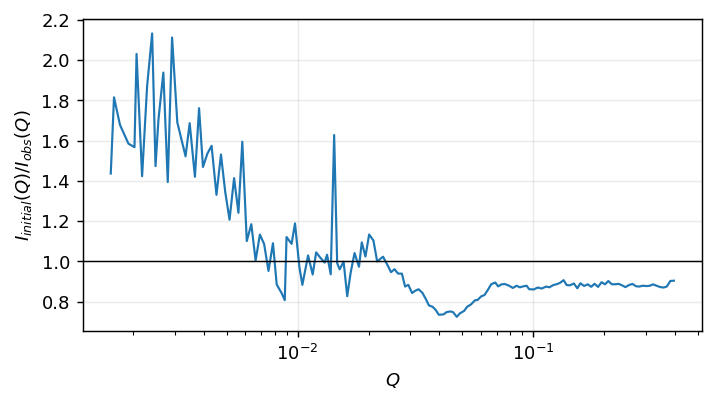

In [12]:
initial_model = cf.evaluate_heterogeneous_line_guess(
    stitched,
    q_bounds=(FIT_Q_MIN, FIT_Q_MAX),
    parameters=fit_initial,
    model_settings=fit_model_settings,
    distribution_parameter_set=fit_distribution_parameter_set,
    log_error_floor=0.04,
)
print(f"[status] initial model cost={initial_model.cost:.6g}")
for key, value in initial_model.parameters.items():
    print(f"[initial] {key} = {value:.6g}")

fig, ax = plt.subplots(figsize=(5.6, 3.9))
positive = stitched.intensity > 0.0
ax.errorbar(
    stitched.q[positive],
    stitched.intensity[positive],
    yerr=stitched.error[positive],
    fmt="o",
    ms=3,
    lw=0.55,
    capsize=2,
    color="k",
    alpha=1,
    label="stitched observation",
    markerfacecolor="none",
)
ax.plot(initial_model.q, initial_model.model, lw=1.5, label="initial guess", color="r", linestyle="-", zorder=20)
ax.axvspan(FIT_Q_MIN, FIT_Q_MAX, color="0.5", alpha=0.08)
ax.axvline(peak_guess["q_peak"], color="0.2", lw=0.8, ls=":", label=r"$Q_{peak}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.5e-3, 4.0e-1)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_initial_guess_fit.png")

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.semilogx(initial_model.q, initial_model.model / initial_model.intensity, lw=1.2)
ax.axhline(1.0, color="k", lw=0.8)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I_{initial}(Q)/I_{obs}(Q)$")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_initial_guess_fit_ratio.png")


In [13]:
hetero_fit = cf.fit_heterogeneous_line_least_squares(
    stitched,
    q_bounds=(FIT_Q_MIN, FIT_Q_MAX),
    initial=fit_initial,
    lowq_kappa_anchor=lowq_dab_fit.parameters["kappa"],
    highq_coefficient_anchor=highq_line_fit.parameters["coefficient"],
    bounds=fit_bounds,
    model_settings=fit_model_settings,
    distribution_parameter_set=fit_distribution_parameter_set,
    max_nfev=32,
    anchor_weight=1.0,
    log_error_floor=0.04,
)
print(f"[status] fit success={hetero_fit.success}, nfev={hetero_fit.nfev}, cost={hetero_fit.cost:.6g}")
print(f"[status] {hetero_fit.message}")
print("[status] fitted parameters")
for key, value in hetero_fit.parameters.items():
    print(f"  {key:20s} {value:.8g}")

with open(OUTPUT_DIR / f"{SAMPLE_TAG}_first_fit_parameters.csv", "w", encoding="utf-8") as fh:
    fh.write("name,value\n")
    for key, value in hetero_fit.parameters.items():
        fh.write(f"{key},{value}\n")
np.savetxt(
    OUTPUT_DIR / f"{SAMPLE_TAG}_first_fit_curve.csv",
    np.column_stack([hetero_fit.q, hetero_fit.intensity, hetero_fit.error, hetero_fit.model, hetero_fit.model / hetero_fit.intensity]),
    delimiter=",",
    header="Q,I_obs,err,I_fit,I_fit_over_I_obs",
    comments="",
)


[status] fit success=True, nfev=12, cost=151.745
[status] `xtol` termination condition is satisfied.
[status] fitted parameters
  scale                35.413914
  mean_k               0.033728193
  r_sigma_k            0.27000027
  k_H_over_k           0.07738513
  b                    -0.82090998
  k_H                  0.0026083737
  p_H                  0.79415123
  sigma_H_squared      0.16347506
  alpha_H              0.00017111783
  kappa_H              0.0010467519
  rho0                 0.0001291516
  highq_coefficient    0.011411082
  skewness             1.2147215


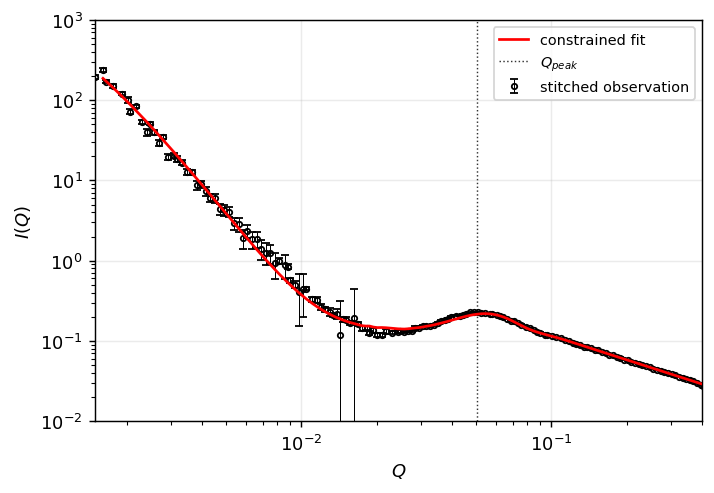

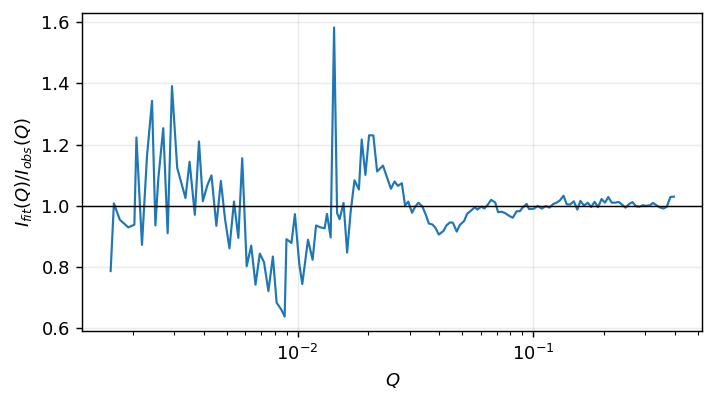

In [14]:
fig, ax = plt.subplots(figsize=(5.6, 3.9))
positive = stitched.intensity > 0.0
ax.errorbar(
    stitched.q[positive],
    stitched.intensity[positive],
    yerr=stitched.error[positive],
    fmt="o",
    ms=3,
    lw=0.55,
    capsize=2,
    color="k",
    alpha=1,
    label="stitched observation",
    markerfacecolor="none",
)
ax.plot(hetero_fit.q, hetero_fit.model, lw=1.5, label="constrained fit", color="r", linestyle="-",zorder=20)
# ax.axvspan(FIT_Q_MIN, FIT_Q_MAX, color="0.5", alpha=0.08)
ax.axvline(peak_guess["q_peak"], color="0.2", lw=0.8, ls=":", label=r"$Q_{peak}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.5e-3, 4.0e-1)
ax.set_ylim(1e-2, 1e3)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_first_constrained_fit.png")

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.semilogx(hetero_fit.q, hetero_fit.model / hetero_fit.intensity, lw=1.2)
ax.axhline(1.0, color="k", lw=0.8)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I_{fit}(Q)/I_{obs}(Q)$")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_first_constrained_fit_ratio.png")


## 3D heterogeneous line preview


In [15]:
try:
    import pyvista as pv
    PYVISTA_AVAILABLE = True
except Exception as exc:
    PYVISTA_AVAILABLE = False
    print(f"[status] PyVista preview unavailable: {exc}")


In [16]:
# 3D preview settings follow project_randomcxl/interactive_rw_hetero.ipynb.
# The line wavenumber is normalized for visualization; fitted k_H/k and p_H are preserved.
RENDER_RANDOM_SEED = 114514
RENDER_K_LINE = 10.0
RENDER_NUM_LINE_MODES = 128
RENDER_NX = 150
RENDER_NY = 150
RENDER_NZ = 8
RENDER_LATERAL_SIZE_OVER_MASK_LENGTH = 15.0
RENDER_THICKNESS_OVER_MASK_LENGTH = 0.8
RENDER_LINE_TUBE_RADIUS_FRACTION = 0.002
RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K = 10.0
RENDER_SHOW_MASK_BOUNDARY = False
RENDER_SHOW_BOX_BOUNDARY = True
RENDER_SHOW_REJECTED_LINES = False
RENDER_WINDOW_SIZE = (800, 800)
RENDER_WINDOW_FILL_FRACTION = 0.95
RENDER_INITIAL_VIEW = "normal"
RENDER_SCREENSHOT_SCALE = 3
RENDER_SCREENSHOT_PATH = OUTPUT_DIR / f"{SAMPLE_TAG}_fit_heterogeneous_preview.png"


In [17]:
if PYVISTA_AVAILABLE:
    pv.set_jupyter_backend("html")
    fit_preview = cf.render_fit_heterogeneous_preview(
        hetero_fit.parameters,
        output_path=RENDER_SCREENSHOT_PATH,
        visual_k_line=RENDER_K_LINE,
        line_k_distribution=fit_model_settings["k_distribution"],
        line_r_sigma_k=hetero_fit.parameters["r_sigma_k"],
        line_k_distribution_params={
            name: hetero_fit.parameters[name]
            for name in fit_distribution_parameter_set
        },
        random_seed=RENDER_RANDOM_SEED,
        num_line_modes=RENDER_NUM_LINE_MODES,
        nx=RENDER_NX,
        ny=RENDER_NY,
        nz=RENDER_NZ,
        lateral_size_over_mask_length=RENDER_LATERAL_SIZE_OVER_MASK_LENGTH,
        thickness_over_mask_length=RENDER_THICKNESS_OVER_MASK_LENGTH,
        line_tube_radius_fraction=RENDER_LINE_TUBE_RADIUS_FRACTION,
        min_retained_line_length_over_k=RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K,
        show_mask_boundary=RENDER_SHOW_MASK_BOUNDARY,
        show_box_boundary=RENDER_SHOW_BOX_BOUNDARY,
        show_rejected_lines=RENDER_SHOW_REJECTED_LINES,
        window_size=RENDER_WINDOW_SIZE,
        window_fill_fraction=RENDER_WINDOW_FILL_FRACTION,
        initial_view=RENDER_INITIAL_VIEW,
        screenshot_scale=RENDER_SCREENSHOT_SCALE,
    )
    print(f"[status] preview saved to {fit_preview.screenshot_path}")
    print(f"[status] traced cells={fit_preview.line_cells}, retained cells={fit_preview.retained_cells}, retained points={fit_preview.retained_points}")
    print(f"[status] visual k_distribution={fit_preview.k_distribution}, r_sigma_k={fit_preview.r_sigma_k:.4g}")
    print(f"[status] visual k_line={fit_preview.k_line:.4g}, visual k_H={fit_preview.k_H:.4g}, p_H={fit_preview.p_H:.4g}")
    fit_preview.plotter.show(jupyter_backend="html")


[status] preview saved to output\55B_R0_fit_heterogeneous_preview.png
[status] traced cells=47159, retained cells=967, retained points=47100
[status] visual k_distribution=max_entropy_radial, r_sigma_k=0.27
[status] visual k_line=10, visual k_H=0.7739, p_H=0.7942


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…